<a href="https://colab.research.google.com/github/anshii1311/Brain-Tumour-Detection-AI/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [4]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [5]:
X.shape

(1000, 2)

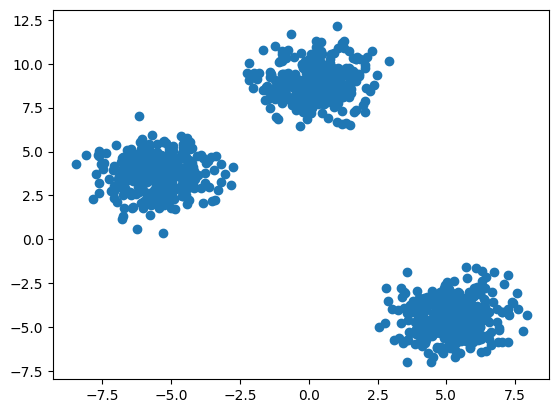

In [6]:
plt.scatter(X[:,0],X[:,1])

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33,random_state=42
)

In [8]:
from sklearn.cluster import KMeans

In [9]:
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train)
  wcss.append(kmeans.inertia_)


In [10]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1174.0930265496456,
 992.7303930989242,
 907.9112063389439,
 767.9920835100206,
 693.7304220179515,
 581.2984101151367,
 592.801425395451]

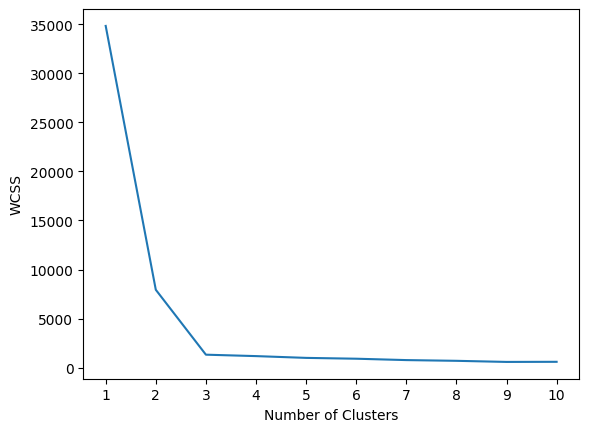

In [11]:
#elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [14]:
y_labels=kmeans.fit_predict(X_train)

In [16]:
kmeans.predict(X_test)

array([1, 1, 1, 0, 2, 1, 0, 0, 2, 0, 1, 1, 2, 0, 1, 0, 0, 1, 2, 1, 1, 1,
       0, 1, 1, 0, 2, 1, 2, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 1, 2, 2, 1,
       0, 2, 0, 1, 1, 0, 2, 1, 0, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1, 0,
       0, 1, 2, 2, 1, 1, 2, 0, 0, 1, 0, 0, 1, 1, 2, 2, 0, 2, 0, 0, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 0, 1, 0, 2, 0, 0, 2, 1, 0, 2, 0, 2, 2, 0, 0,
       2, 2, 0, 2, 0, 2, 2, 1, 2, 2, 2, 2, 0, 2, 0, 0, 2, 1, 2, 0, 2, 1,
       1, 2, 0, 2, 1, 0, 1, 1, 2, 2, 2, 1, 2, 2, 0, 0, 0, 0, 1, 2, 2, 1,
       1, 2, 1, 1, 0, 0, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 1, 2, 1, 1, 2, 2,
       2, 0, 0, 1, 0, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 0, 2, 2, 2, 0, 2, 2,
       0, 0, 1, 1, 0, 1, 0, 2, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2,
       0, 1, 2, 0, 2, 1, 1, 2, 1, 1, 1, 1, 2, 0, 2, 2, 0, 1, 0, 1, 2, 1,
       1, 2, 1, 0, 1, 1, 2, 1, 0, 0, 0, 1, 0, 2, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 2, 1, 0, 0, 2, 0, 2, 2, 2, 0, 1, 2, 1, 2, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 0, 0, 1,

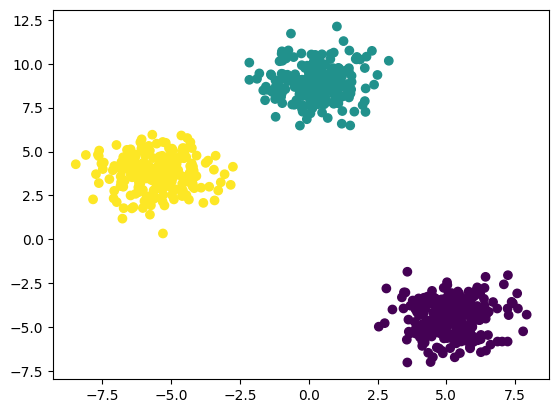

In [15]:
plt.scatter(X_train[:,0],X_train[:,1],c=y_labels)

In [17]:
#knee locator
!pip install kneed

In [18]:
from kneed import KneeLocator

In [21]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction = 'decreasing')#decreasing graph then covex
kl.elbow

np.int64(3)

In [22]:
from sklearn.metrics import silhouette_score

In [25]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficients.append(score)


In [26]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.4895647834796006),
 np.float64(0.33367872107343594),
 np.float64(0.32906393472353807),
 np.float64(0.32155550587038834),
 np.float64(0.3390253793461801),
 np.float64(0.3381162575398305)]

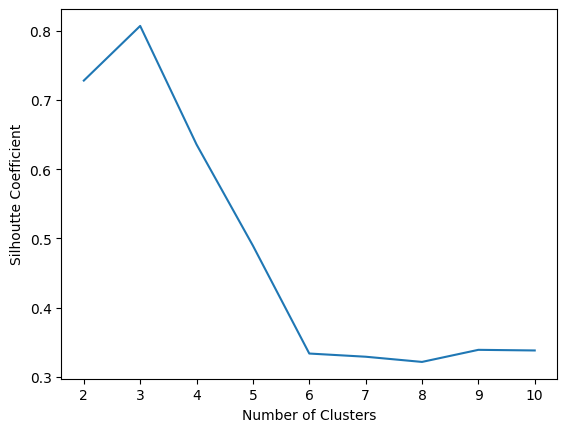

In [29]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutte Coefficient")
plt.show()